## PYQ

#### Write a program to compute the mean, variance and standard deviation of a given data set.

In [1]:
import pandas as pd

df = pd.read_csv("Demo.csv")

In [2]:
df

,ID,Name,Marks,Age
0,1,Shivam,85,22
1,2,Rahul,78,21
2,3,Aman,90,23
3,4,Neha,88,22
4,5,Priya,76,21


In [8]:
# Mean
print("Mean of Marks:", df['Marks'].mean())

# Variance
print("Variance of Marks:", df['Marks'].var())

# standard deviation
print("standard deviation of Marks:", df['Marks'].std())

Mean of Marks: 83.4
Variance of Marks: 37.8
standard deviation of Marks: 6.148170459575759


#### Write a program to calculate the correlation coefficient based on regression coefficients

In [2]:
import math

def correlation_from_regression(b_xy, b_yx):
    # Calculate magnitude of correlation coefficient
    r = math.sqrt(b_xy * b_yx)
    
    # Determine sign (same as regression coefficients)
    if b_xy < 0 and b_yx < 0:
        r = -r
    
    return r

# Example values
b_xy = 0.5
b_yx = 0.8

r = correlation_from_regression(b_xy, b_yx)

print("Correlation coefficient (r):", r)

Correlation coefficient (r): 0.6324555320336759


#### Write a program to fit Binomial distribution on a given data. Provide Example Dataset

In [3]:
import math
import pandas as pd

def binomial_pmf(n, x, p):
    return math.comb(n, x) * (p ** x) * ((1 - p) ** (n - x))

def fit_binomial(data):
    # Total observations
    N = sum(data.values())
    
    # Calculate mean
    mean = sum(x * f for x, f in data.items()) / N
    
    # Assume n = max value in data
    n = max(data.keys())
    
    # Estimate p
    p = mean / n
    
    print(f"Estimated Parameters: n = {n}, p = {p:.4f}")
    
    # Compute expected frequencies
    result = []
    for x in range(n + 1):
        prob = binomial_pmf(n, x, p)
        expected = N * prob
        observed = data.get(x, 0)
        
        result.append([x, observed, round(expected, 2)])
    
    df = pd.DataFrame(result, columns=["x", "Observed", "Expected"])
    print("\nFitted Binomial Distribution:")
    print(df)

# Example Dataset
# Number of successes (x) : frequency
data = {
    0: 5,
    1: 9,
    2: 15,
    3: 12,
    4: 6,
    5: 3
}

fit_binomial(data)

Estimated Parameters: n = 5, p = 0.4560

Fitted Binomial Distribution:
   x  Observed  Expected
0  0         5      2.38
1  1         9      9.98
2  2        15     16.74
3  3        12     14.03
4  4         6      5.88
5  5         3      0.99


#### Write a program to plot a bar chart in python to display the important sources of GDP of India.

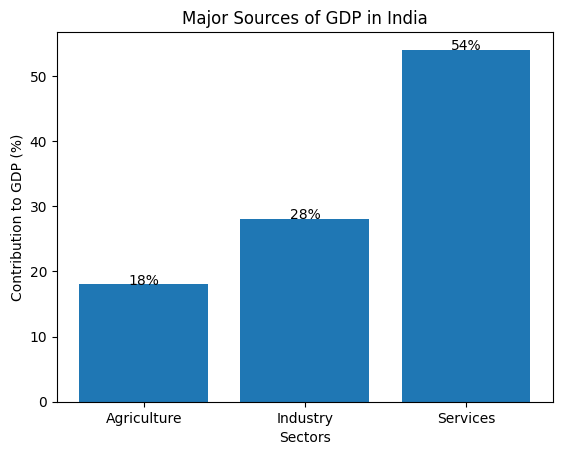

In [4]:
import matplotlib.pyplot as plt

sectors = ['Agriculture', 'Industry', 'Services']
contribution = [18, 28, 54]

plt.bar(sectors, contribution)

plt.xlabel('Sectors')
plt.ylabel('Contribution to GDP (%)')
plt.title('Major Sources of GDP in India')

for i in range(len(sectors)):
    plt.text(i, contribution[i], str(contribution[i]) + '%', ha='center')

plt.show()

#### Write a Python class to implement a simple queue using a list. Include methods to enqueue (add) and dequeue (remove) items

In [5]:
class Queue:
    def __init__(self):
        self.queue = []

    # Enqueue: Add item to the rear
    def enqueue(self, item):
        self.queue.append(item)
        print(f"{item} added to queue")

    # Dequeue: Remove item from the front
    def dequeue(self):
        if self.is_empty():
            print("Queue is empty")
            return None
        return self.queue.pop(0)

    # Check if queue is empty
    def is_empty(self):
        return len(self.queue) == 0

    # Display queue
    def display(self):
        print("Queue:", self.queue)


# Example usage
q = Queue()

q.enqueue(10)
q.enqueue(20)
q.enqueue(30)

q.display()

print("Removed:", q.dequeue())

q.display()

10 added to queue
20 added to queue
30 added to queue
Queue: [10, 20, 30]
Removed: 10
Queue: [20, 30]


#### Write a program to find the EOQ using any one deterministic inventory model.

In [6]:
import math

class EOQModel:
    def __init__(self, demand, ordering_cost, holding_cost):
        self.D = demand
        self.S = ordering_cost
        self.H = holding_cost

    def calculate_eoq(self):
        eoq = math.sqrt((2 * self.D * self.S) / self.H)
        return eoq

    def display(self):
        eoq = self.calculate_eoq()
        print("Annual Demand (D):", self.D)
        print("Ordering Cost (S):", self.S)
        print("Holding Cost (H):", self.H)
        print("Economic Order Quantity (EOQ):", round(eoq, 2))


# Example values
model = EOQModel(demand=1000, ordering_cost=50, holding_cost=2)
model.display()

Annual Demand (D): 1000
Ordering Cost (S): 50
Holding Cost (H): 2
Economic Order Quantity (EOQ): 223.61


#### Write a program to implement linear regression using python.

In [7]:
import numpy as np

class LinearRegression:
    def __init__(self):
        self.b0 = 0  # intercept
        self.b1 = 0  # slope

    def fit(self, X, Y):
        X = np.array(X)
        Y = np.array(Y)
        
        x_mean = np.mean(X)
        y_mean = np.mean(Y)
        
        numerator = np.sum((X - x_mean) * (Y - y_mean))
        denominator = np.sum((X - x_mean) ** 2)
        
        self.b1 = numerator / denominator
        self.b0 = y_mean - self.b1 * x_mean

    def predict(self, X):
        return self.b0 + self.b1 * np.array(X)

    def display(self):
        print(f"Regression Equation: y = {self.b0:.2f} + {self.b1:.2f}x")


# Example dataset
X = [1, 2, 3, 4, 5]
Y = [2, 4, 5, 4, 5]

# Model training
model = LinearRegression()
model.fit(X, Y)

# Display equation
model.display()

# Prediction
predictions = model.predict(X)
print("Predicted values:", predictions)

Regression Equation: y = 2.20 + 0.60x
Predicted values: [2.8 3.4 4.  4.6 5.2]


#### Write a program in python to plot a histogram of a given data set.

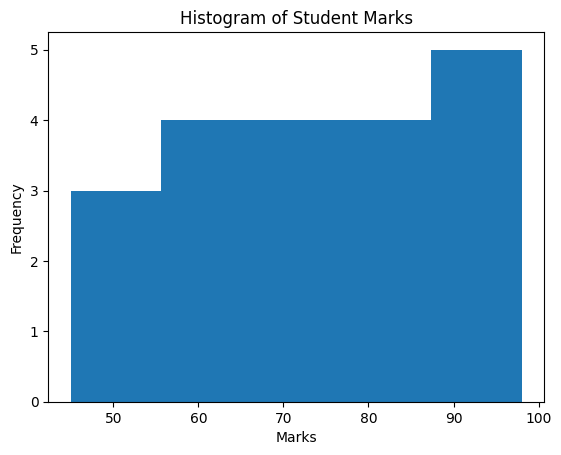

In [8]:
import matplotlib.pyplot as plt

# Sample dataset (e.g., marks of students)
data = [45, 50, 52, 56, 60, 62, 65, 68, 70, 72,
        75, 78, 80, 82, 85, 88, 90, 92, 95, 98]

# Plot histogram
plt.hist(data, bins=5)

# Labels and title
plt.xlabel('Marks')
plt.ylabel('Frequency')
plt.title('Histogram of Student Marks')

# Show plot
plt.show()

#### Write a program to test the significance of two samples have been drawn from the same Normal population.

In [9]:
import numpy as np
from scipy import stats

# Sample data (example)
sample1 = [12, 15, 14, 10, 13, 16, 18, 17]
sample2 = [22, 25, 24, 20, 23, 26, 28, 27]

# Perform independent t-test
t_stat, p_value = stats.ttest_ind(sample1, sample2)

print("t-statistic:", round(t_stat, 4))
print("p-value:", round(p_value, 4))

# Decision at 5% significance level
alpha = 0.05
if p_value < alpha:
    print("Reject H0: Samples are from different populations")
else:
    print("Fail to reject H0: Samples are from same population")

t-statistic: -7.4927
p-value: 0.0
Reject H0: Samples are from different populations
